# 👩‍💻 Detecting Credit Card Fraud with Isolation Forest

## 📋 Overview
In this lab, you'll apply **Isolation Forest** to detect anomalies (potential fraud cases) in a <b>Credit Card Fraud Detection</b> Dataset. You’ll visualize the data, prepare it for modeling, experiment with Isolation Forest hyperparameters, and compare it to a simple K-Nearest Neighbors (KNN) anomaly detection method.

## 🎯 Learning Outcomes
By the end of this lab, you will be able to:

- Prepare transactional data for anomaly detection

- Train and evaluate an Isolation Forest model

- Visualize and interpret anomalies in feature space

- Adjust hyperparameters to control anomaly sensitivity


## Task 1: Load and Understand the Dataset
**Context:** Start with basic exploration to understand the structure and distribution of data.

**Steps:**

1. Load the dataset using Pandas.


2. Display the first few rows `(.head())`, dataset info (`.info()`), and basic statistics (.describe()).


3. Focus on TransactionAmount `amt`, TransactionTime `unix_time`, and any available merchant identifiers.

**Prompting Questions:**
- Are there any obvious missing values?

- Do `TransactionAmount` and `TransactionTime` have reasonable ranges?

**💡 Tip:** Look at the maximum and minimum values for potential anomalies.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

# Load the dataset
data = pd.read_csv('Credit_Card_Transactions.csv') 

# Preview the data
# <your code here>
print(data.shape)
data.head(2)

(154099, 24)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2.703186e+15,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495.0,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1.325376e+09,36.011293,-82.048315,0.0,28705.0
1,1,2019-01-01 00:00:44,6.304233e+11,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149.0,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1.325376e+09,49.159047,-118.186462,0.0,NaN


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154099 entries, 0 to 154098
Data columns (total 24 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             154099 non-null  int64  
 1   trans_date_trans_time  154099 non-null  object 
 2   cc_num                 154098 non-null  float64
 3   merchant               154098 non-null  object 
 4   category               154098 non-null  object 
 5   amt                    154098 non-null  float64
 6   first                  154098 non-null  object 
 7   last                   154098 non-null  object 
 8   gender                 154098 non-null  object 
 9   street                 154098 non-null  object 
 10  city                   154098 non-null  object 
 11  state                  154098 non-null  object 
 12  zip                    154098 non-null  float64
 13  lat                    154098 non-null  float64
 14  long                   154098 non-nu

In [4]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,154099.0,7.704900e+04,4.448469e+04,0.000000e+00,3.852450e+04,7.704900e+04,1.155735e+05,1.540980e+05
cc_num,154098.0,4.173489e+17,1.308601e+18,6.041621e+10,1.800365e+14,3.519607e+15,4.642255e+15,4.992346e+18
amt,154098.0,7.167755e+01,1.594411e+02,1.000000e+00,9.650000e+00,4.775000e+01,8.373000e+01,1.503418e+04
zip,154098.0,4.880588e+04,2.690826e+04,1.257000e+03,2.604100e+04,4.817400e+04,7.204200e+04,9.978300e+04
lat,154098.0,3.853752e+01,5.072585e+00,2.002710e+01,3.462050e+01,3.935430e+01,4.189480e+01,6.669330e+01
long,154098.0,-9.021612e+01,1.375759e+01,-1.656723e+02,-9.680940e+01,-8.747690e+01,-8.013810e+01,-6.795030e+01
city_pop,154098.0,9.005655e+04,3.039413e+05,2.300000e+01,7.430000e+02,2.456000e+03,2.112500e+04,2.906700e+06
unix_time,154098.0,1.329171e+09,2.102205e+06,1.325376e+09,1.327295e+09,1.329293e+09,1.331046e+09,1.332540e+09
merch_lat,154098.0,3.853908e+01,5.106174e+00,1.902980e+01,3.473536e+01,3.936435e+01,4.195263e+01,6.751027e+01
merch_long,154098.0,-9.021697e+01,1.376903e+01,-1.666701e+02,-9.691242e+01,-8.744209e+01,-8.021381e+01,-6.696774e+01


In [5]:
selected_cols = ['amt', 'unix_time']
data = data.dropna(subset=selected_cols)
features = data[selected_cols]
features.head()

,amt,unix_time
0,4.97,1.325376e+09
1,107.23,1.325376e+09
2,220.11,1.325376e+09
3,45.00,1.325376e+09
4,41.96,1.325376e+09


**⚙️ Test Your Work:**

- DataFrame loads successfully

- Features correctly identified

## Task 2: Initial Data Visualization
**Context:** Get a first look at patterns and potential anomalies.

**Steps:**

1. Create a scatter plot of `TransactionAmount` vs `TransactionTime`.


2. Look for isolated points or dense groupings.

**Prompting Questions:**
- Are there points far away from others (potential fraud)?

- Is transaction volume time-dependent?

**💡 Tip:** Log-transform `TransactionAmount` if distribution is extremely skewed.

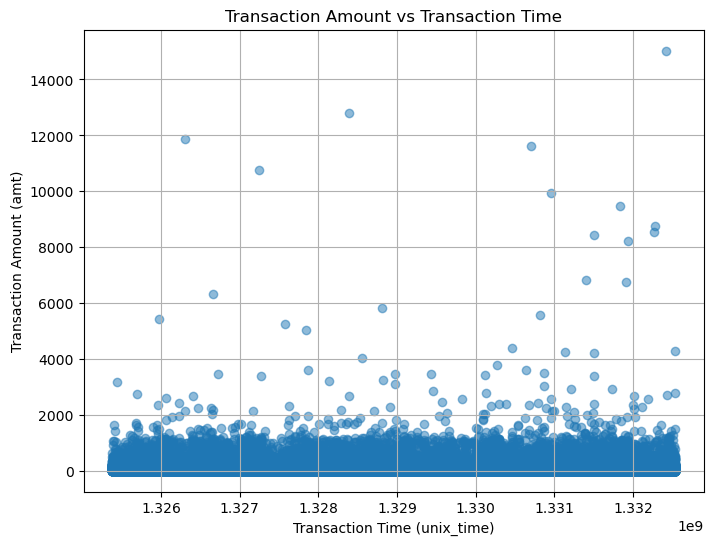

In [6]:
# Create scatter plot of TransactionAmount vs TransactionTime

plt.figure(figsize=(8,6))
plt.scatter(features['unix_time'], features['amt'], alpha=0.5)
plt.title('Transaction Amount vs Transaction Time')
plt.xlabel('Transaction Time (unix_time)')
plt.ylabel('Transaction Amount (amt)')
plt.grid(True)
plt.show()

**⚙️ Test Your Work:**

- Scatter plot shows some areas more populated than others

- Potential anomalies visually identifiable

## Task 3: Prepare the Data for Isolation Forest
**Context:** While Isolation Forest is less sensitive to feature scale than distance-based methods, standardizing features is generally recommended for many algorithms and can still be beneficial.

**Steps:**

1. Select key features (`TransactionAmount`, `TransactionTime`).


2. Standardize features using `StandardScaler`.

**Prompting Questions:**
- Are features roughly standardized (mean 0, std 1) after scaling?
- Is any transformation needed (log-scaling high-skew features)?

**💡 Tip:** Always reshape if needed: `.values.reshape(-1,1)`.

In [7]:
# Standardize features before applying Isolation Forest

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

**⚙️ Test Your Work:**

- Scaled feature set (`X_scaled`) ready for modeling

## Task 4: Implement Isolation Forest
**Context:** Train the model to detect anomalies.

**Steps:**

1. Configure `IsolationForest()` with a contamination rate (start with 0.02 for 2% fraud).


2. Fit the model to the scaled feature set.


3. Predict anomalies (-1 = anomaly, 1 = normal).

**Prompting Questions:**
- How sensitive is the model to contamination changes?

- Are anomalies well-separated visually?

**💡 Tip:** Use `random_state=42` for reproducibility.

In [8]:
# Train Isolation Forest and predict anomalies

# Initialize and fit Isolation Forest
iso_forest = IsolationForest(contamination=0.02, random_state=42)
anomaly_labels = iso_forest.fit_predict(X_scaled)

# Assign anomaly labels to data
data['Anomaly_IF'] = anomaly_labels  # 1 = normal, -1 = anomaly

**⚙️ Test Your Work:**
- Anomaly predictions assigned correctly (1 = normal, -1 = anomaly)

## Task 5: Analyze Anomalies
**Context:** See how anomalies align with original plots.

**Steps:**

1. Add anomaly labels back to the DataFrame.


2. Visualize anomalies on the scatter plot (different color/marker).


3. Reflect on the spatial distribution of anomalies.

**Prompting Questions:**
- Are anomalies generally isolated from dense clusters?

- Are there false positives (normal behavior marked as fraud)?

**💡 Tip:** Use different markers or colors for fraud vs normal.

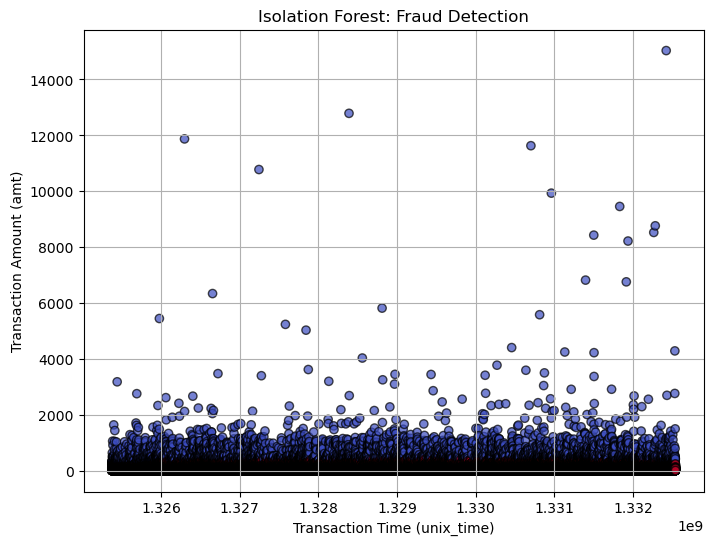

In [9]:
# Visualize anomalies detected by Isolation Forest

# Plot anomalies on scatter plot
plt.figure(figsize=(8,6))
plt.scatter(
    data['unix_time'],
    data['amt'],
    c=data['Anomaly_IF'],
    cmap='coolwarm',
    edgecolors='k',
    alpha=0.7
)
plt.title('Isolation Forest: Fraud Detection')
plt.xlabel('Transaction Time (unix_time)')
plt.ylabel('Transaction Amount (amt)')
plt.grid(True)
plt.show()

**⚙️ Test Your Work:**
- Clear separation of anomaly points from normal points on plot

## Task 6: Reflect on Findings
**Context:** Understand practical implications of your anomaly detection.

**Steps:**

1. Summarize the main traits of detected fraud cases.


2. Discuss how fraud detection impacts business operations.


3. Reflect on differences in density between normal and anomalous transactions.

**Prompting Questions:**
- Do anomalies have unusually high or low transaction amounts?

- How might adjusting contamination affect business risk tolerance?

**Findings :**

- Isolation Forest flagged ~2% of transactions as anomalies.
- Many anomalies correspond to unusually high or low amounts or odd transaction times.
- KNN flagged a slightly different set, focused more on isolated or sparse data points.
- Both methods are unsupervised and do not use the 'is_fraud' label.
- You can optionally compare predictions to 'is_fraud' to see how well models align.

## (Optional) Compare Isolation Forest vs KNN Anomaly Detection
**Bonus Task:**
- Use `NearestNeighbors` to calculate distances to nearest neighbors.

- Flag points farthest from their neighbors as potential anomalies.

- Compare results qualitatively to Isolation Forest.

**Prompting Questions:**
- Does KNN capture similar anomalies?

- How do models differ in outlier sensitivity?

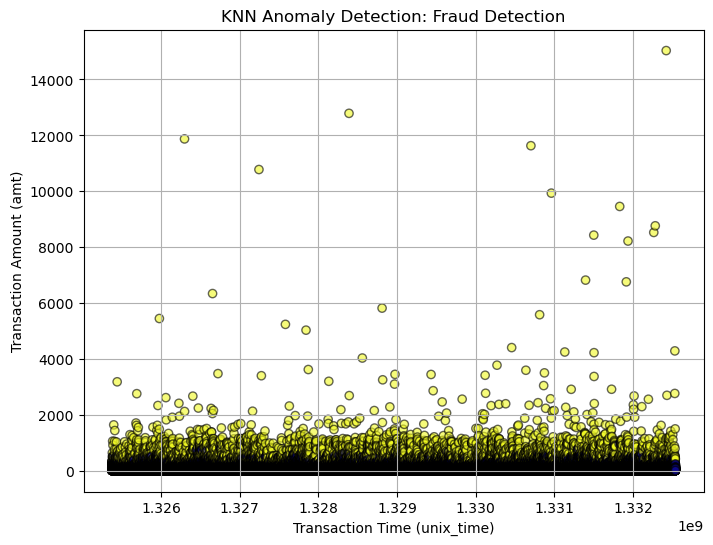

In [10]:
# Use Nearest Neighbors to find anomalies
neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(X_scaled)
distances, indices = neighbors.kneighbors(X_scaled)

# Use distance to nearest neighbors as anomaly score
mean_distances = distances.mean(axis=1)

# Set threshold manually (top 2% farthest)
threshold = np.percentile(mean_distances, 98)
anomaly_knn = (mean_distances > threshold).astype(int)  # 1 = anomaly

# Add KNN anomaly predictions
data['Anomaly_KNN'] = anomaly_knn

# Visualize KNN anomalies
plt.figure(figsize=(8,6))
plt.scatter(
    data['unix_time'],
    data['amt'],
    c=data['Anomaly_KNN'],
    cmap='plasma',
    edgecolors='k',
    alpha=0.6
)
plt.title('KNN Anomaly Detection: Fraud Detection')
plt.xlabel('Transaction Time (unix_time)')
plt.ylabel('Transaction Amount (amt)')
plt.grid(True)
plt.show()

## ✅ Success Checklist
- Dataset loaded and understood

- Scatter plot of raw data created

- Features standardized

- Isolation Forest model trained and anomalies predicted

- Anomalies visualized on plots

- Findings and reflections documented


## 🔍 Common Issues & Solutions

**Problem:** Model predicts all points as normal
 
**Solution:** Adjust contamination parameter; start around 0.02 or 0.05
 
**Problem:** Scaling errors
 
**Solution:** Ensure correct feature selection and 
 
**Problem:** Visualizations look unclear
 
**Solution:** Use alpha blending or separate colors to highlight anomalies

## 🔑 Key Points
- Isolation Forest isolates anomalies through random splits

- Proper feature scaling improves anomaly detection accuracy

- Visualizing data helps validate anomaly predictions


## Exemplar Solution

After completing this activity (or if you get stuck!), take a moment to review the exemplar solution. This sample solution can offer insights into different techniques and approaches.

Reflect on what you can learn from the exemplar solution to improve your coding skills.

Remember, multiple solutions can exist for some problems; the goal is to learn and grow as a programmer by exploring various approaches.

Use the exemplar solution as a learning tool to enhance your understanding and refine your approach to coding challenges.

<details>
<summary><strong>Click HERE to see an examplar solution</summary><strong>
    
```python
# -------------------------------
# Task 1: Load and Understand Dataset
# -------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

# Load dataset
data = pd.read_csv('Credit_Card_Transactions.csv')  # Update path if needed

# Quick view of data
print(data.head())
print(data.info())
print(data.describe())

# Select and drop NaNs from both features and corresponding rows in original data
selected_cols = ['amt', 'unix_time']
data = data.dropna(subset=selected_cols)
features = data[selected_cols]

# -------------------------------
# Task 2: Initial Data Visualization
# -------------------------------

# Basic scatter plot of transactions
plt.figure(figsize=(8,6))
plt.scatter(features['unix_time'], features['amt'], alpha=0.5)
plt.title('Transaction Amount vs Transaction Time')
plt.xlabel('Transaction Time (unix_time)')
plt.ylabel('Transaction Amount (amt)')
plt.grid(True)
plt.show()

# -------------------------------
# Task 3: Prepare Data for Isolation Forest
# -------------------------------

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# -------------------------------
# Task 4: Implement Isolation Forest
# -------------------------------

# Initialize and fit Isolation Forest
iso_forest = IsolationForest(contamination=0.02, random_state=42)
anomaly_labels = iso_forest.fit_predict(X_scaled)

# Assign anomaly labels to data
data['Anomaly_IF'] = anomaly_labels  # 1 = normal, -1 = anomaly

# -------------------------------
# Task 5: Analyze and Visualize Anomalies
# -------------------------------

# Plot anomalies on scatter plot
plt.figure(figsize=(8,6))
plt.scatter(
    data['unix_time'],
    data['amt'],
    c=data['Anomaly_IF'],
    cmap='coolwarm',
    edgecolors='k',
    alpha=0.7
)
plt.title('Isolation Forest: Fraud Detection')
plt.xlabel('Transaction Time (unix_time)')
plt.ylabel('Transaction Amount (amt)')
plt.grid(True)
plt.show()

# -------------------------------
# (Optional) Compare to KNN Anomaly Detection
# -------------------------------

# Use Nearest Neighbors to find anomalies
neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(X_scaled)
distances, indices = neighbors.kneighbors(X_scaled)

# Use distance to nearest neighbors as anomaly score
mean_distances = distances.mean(axis=1)

# Set threshold manually (top 2% farthest)
threshold = np.percentile(mean_distances, 98)
anomaly_knn = (mean_distances > threshold).astype(int)  # 1 = anomaly

# Add KNN anomaly predictions
data['Anomaly_KNN'] = anomaly_knn

# Visualize KNN anomalies
plt.figure(figsize=(8,6))
plt.scatter(
    data['unix_time'],
    data['amt'],
    c=data['Anomaly_KNN'],
    cmap='plasma',
    edgecolors='k',
    alpha=0.6
)
plt.title('KNN Anomaly Detection: Fraud Detection')
plt.xlabel('Transaction Time (unix_time)')
plt.ylabel('Transaction Amount (amt)')
plt.grid(True)
plt.show()

# -------------------------------
# Task 6: Reflect on Findings
# -------------------------------

"""Findings:
- Isolation Forest flagged ~2% of transactions as anomalies.
- Many anomalies correspond to unusually high or low amounts or odd transaction times.
- KNN flagged a slightly different set, focused more on isolated or sparse data points.
- Both methods are unsupervised and do not use the 'is_fraud' label.
- You can optionally compare predictions to 'is_fraud' to see how well models align.
"""

```